# Phân khúc khách hàng — K-Medoids (PAM) từ Scratch

## Bài toán

**Customer Personality Analysis** là bài toán khai phá cấu trúc tiềm ẩn từ hồ sơ khách hàng của doanh nghiệp. Dữ liệu gồm hai nhóm thông tin chính:

- **Nhân khẩu học:** tuổi, thu nhập, trình độ học vấn, tình trạng hôn nhân, số con trong gia đình, thời gian gắn bó với công ty.
- **Hành vi mua sắm & marketing:** chi tiêu theo từng nhóm sản phẩm, kênh mua (web, catalogue, cửa hàng), tần suất truy cập web, phản hồi các chiến dịch khuyến mãi.

Mục tiêu là **gom nhóm khách hàng có đặc điểm tương đồng** để doanh nghiệp tối ưu chăm sóc, cá nhân hóa marketing và tập trung ngân sách vào phân khúc có tiềm năng cao thay vì tiếp cận toàn bộ cơ sở dữ liệu.

## Mục tiêu

1. Tiền xử lý và khám phá dữ liệu khách hàng đã chuẩn hóa.
2. Cài đặt thuật toán **K-Medoids (PAM)** và **Silhouette Score** từ scratch.
3. Xác định số cụm *K* phù hợp bằng Elbow Method và Silhouette Score.
4. Phân cụm, mô tả chân dung từng phân khúc và xuất kết quả phục vụ chiến lược marketing.

## Input

| Thành phần | Mô tả |
|---|---|
| **File dữ liệu** | `customer_personality_preprocessed.csv` — 2.237 khách hàng × 24 đặc trưng số đã chuẩn hóa |
| **Đặc trưng** | Education, Marital_Status, Income, MntWines/Fruits/Meat/Fish/Sweet/Gold, NumDeals/Web/Catalog/Store Purchases, NumWebVisitsMonth, AcceptedCmp1–5, Response, Complain, DaysCustomer, Age, children |
| **Thuật toán** | K-Medoids (PAM) với khởi tạo K-Medoids++, khoảng cách Euclidean |

## Output

| Thành phần | Mô tả |
|---|---|
| **Nhãn cụm** | Cột `Cluster` (0, 1, 2, 3) gán cho từng khách hàng |
| **Medoids** | Điểm đại diện thực tế của mỗi cụm (khách hàng cụ thể trong tập dữ liệu) |
| **Bảng chân dung** | Giá trị trung bình chuẩn hóa theo từng phân khúc |
| **File kết quả** | `customer_personality_clustered_v2.csv` (2.237 dòng × 25 cột) |
| **Biểu đồ** | PCA 2D, Elbow/Silhouette, scatter phân khúc kèm medoids |

## Mục lục

1. **[Giai đoạn 1]** Tìm hiểu và chuẩn bị dữ liệu
2. **[Giai đoạn 2]** Định nghĩa thuật toán K-Medoids từ scratch
3. **[Giai đoạn 3]** Huấn luyện mô hình — chọn *K* tối ưu
4. **[Giai đoạn 4]** Đánh giá & báo cáo kết quả phân khúc


### **[GIAI ĐOẠN 1]: TÌM HIỂU VÀ CHUẨN BỊ DỮ LIỆU**
- Import thư viện.
- Đọc dữ liệu.
- Trực quan hoá dữ liệu thô.

In [1]:
# ==============================================================================
# IMPORT CÁC THƯ VIỆN CẦN THIẾT
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình để hiển thị biểu đồ đẹp hơn trong Jupyter
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# ==============================================================================
# ĐỌC DỮ LIỆU 
# ==============================================================================
try:
    df = pd.read_csv('customer_personality_preprocessed.csv')
    print("Nạp dữ liệu thành công! Kích thước tập dữ liệu:", df.shape)
    
    # Chuyển đổi dataframe thành mảng Numpy (chỉ lấy các cột số đã được chuẩn hóa)
    X = df.values
    print("Dữ liệu đã được chuyển sang ma trận Numpy, sẵn sàng tính toán.")
except FileNotFoundError:
    print("Không tìm thấy file 'customer_personality_preprocessed.csv'. Hãy kiểm tra lại đường dẫn.")

Nạp dữ liệu thành công! Kích thước tập dữ liệu: (2237, 24)
Dữ liệu đã được chuyển sang ma trận Numpy, sẵn sàng tính toán.


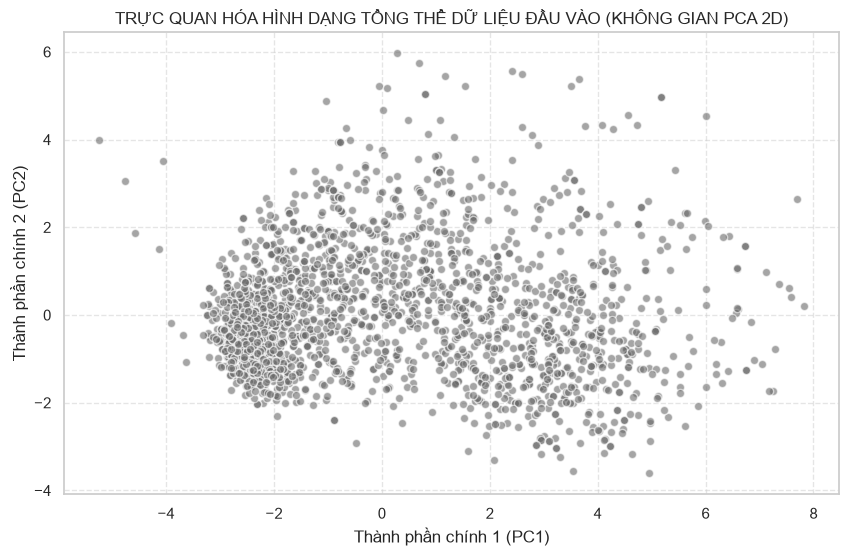

In [3]:
# ==============================================================================
# PCA FROM SCRATCH — hàm tái sử dụng
# ==============================================================================

def pca_project(X, n_components=2):
    """Mean-center → covariance → eigen → chiếu xuống n_components chiều."""
    mean = np.mean(X, axis=0)
    X_centered = X - mean
    cov_matrix = np.cov(X_centered, rowvar=False)
    eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)
    sorted_index = np.argsort(eigen_values)[::-1]
    components = eigen_vectors[:, sorted_index[:n_components]]
    X_proj = X_centered @ components
    return X_proj, components, mean


def pca_transform(X, components, mean):
    """Chiếu điểm (hoặc medoids) xuống không gian PCA đã học."""
    return (X - mean) @ components


# ==============================================================================
# TRỰC QUAN HÓA DỮ LIỆU ĐẦU VÀO (PCA 2D)
# ==============================================================================
X_pca, pca_components, X_mean = pca_project(X, n_components=2)

# 6. Vẽ biểu đồ phân tán (Scatter plot) dữ liệu thô ban đầu
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color='dimgray', edgecolors='w', s=35)
plt.title('TRỰC QUAN HÓA HÌNH DẠNG TỔNG THỂ DỮ LIỆU ĐẦU VÀO (KHÔNG GIAN PCA 2D)')
plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Nhận xét — Khám phá dữ liệu (PCA 2D)

- Tập dữ liệu gồm **2.237 khách hàng** với **24 đặc trưng số** đã được chuẩn hóa, sẵn sàng cho phân cụm.
- Biểu đồ PCA cho thấy dữ liệu **không phân tách rõ ràng** thành các vùng tách biệt trong không gian 2 chiều — điều này phù hợp với bản chất phân cụm trên nhiều chiều (nhân khẩu học + hành vi + marketing).
- Các điểm phân bố dày đặc ở trung tâm với một số nhánh kéo dài, gợi ý tồn tại **nhóm khách hàng ngoại lai** (outlier) và **đa dạng mức chi tiêu** — đây là lý do chọn K-Medoids thay vì K-Means: medoid là điểm thực tế, ít bị ảnh hưởng bởi giá trị cực đoan.


### **[GIAI ĐOẠN 2]: ĐỊNH NGHĨA THUẬT TOÁN K-MEDOIDS TỪ SCRATCH**
- Định nghĩa lớp **KMedoidsFromScratch** (PAM — hoán đổi medoid, lưu `medoid_indices_`)
- Hàm **Silhouette Score** from scratch (dùng ma trận khoảng cách tiền tính)


In [4]:
# ==============================================================================
# Định nghĩa lớp K-MEDOIDS FROM SCRATCH
# ==============================================================================

class KMedoidsFromScratch:
    def __init__(self, n_clusters=3, max_iters=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.medoids = None
        self.medoid_indices_ = None
        self.labels = None
        self.total_cost_ = None

    def _init_medoids_plusplus(self, X):
        """Khởi tạo medoids theo phương pháp K-Medoids++ (lưu index, tránh trùng)."""
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        chosen = [np.random.randint(0, n_samples)]

        for _ in range(1, self.n_clusters):
            medoids = X[chosen]
            dists = np.min(
                np.linalg.norm(X[:, np.newaxis] - medoids, axis=2),
                axis=1
            )
            remaining = np.setdiff1d(np.arange(n_samples), chosen)
            if len(remaining) == 0:
                break
            probs = dists[remaining] / dists[remaining].sum()
            chosen.append(np.random.choice(remaining, p=probs))

        return np.array(chosen, dtype=int)

    def _assign_clusters(self, X):
        """Gán nhãn cho mỗi điểm dựa trên khoảng cách đến medoids gần nhất."""
        return self._assign_clusters_with_medoids(X, self.medoids)

    def _assign_clusters_with_medoids(self, X, medoids):
        """Gán cụm theo bộ medoids cho trước."""
        distances = np.linalg.norm(X[:, np.newaxis] - medoids, axis=2)
        return np.argmin(distances, axis=1)

    def _compute_cost(self, X, labels, medoid_indices):
        """Total Cost khi biết nhãn cụm và index medoid."""
        cost = 0.0
        for i, idx in enumerate(medoid_indices):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                cost += np.sum(np.linalg.norm(cluster_points - X[idx], axis=1))
        return cost

    def _compute_total_cost(self, X):
        """Total Cost = tổng khoảng cách từ mỗi điểm đến medoid gần nhất."""
        distances = np.linalg.norm(X[:, np.newaxis] - self.medoids, axis=2)
        return np.sum(np.min(distances, axis=1))

    def fit(self, X):
        """Huấn luyện mô hình K-Medoids bằng thuật toán PAM (hoán đổi medoid)."""
        X = np.asarray(X)
        n_samples = X.shape[0]
        self.medoid_indices_ = self._init_medoids_plusplus(X)
        self.medoids = X[self.medoid_indices_].copy()
        medoid_set = set(self.medoid_indices_.tolist())

        for iteration in range(self.max_iters):
            self.labels = self._assign_clusters(X)
            current_cost = self._compute_cost(X, self.labels, self.medoid_indices_)
            improved = False

            for i in range(self.n_clusters):
                for j in range(n_samples):
                    if j in medoid_set:
                        continue

                    new_indices = self.medoid_indices_.copy()
                    new_indices[i] = j
                    new_medoids = X[new_indices]
                    new_labels = self._assign_clusters_with_medoids(X, new_medoids)
                    new_cost = self._compute_cost(X, new_labels, new_indices)

                    if new_cost < current_cost:
                        self.medoid_indices_ = new_indices
                        self.medoids = new_medoids.copy()
                        medoid_set = set(self.medoid_indices_.tolist())
                        current_cost = new_cost
                        improved = True
                        break
                if improved:
                    break

            if not improved:
                print(f"Hội tụ sau {iteration + 1} vòng lặp.")
                break

        self.labels = self._assign_clusters(X)
        self.total_cost_ = self._compute_total_cost(X)
        return self

    def predict(self, X):
        """Dự đoán nhãn cho dữ liệu mới"""
        if self.medoids is None:
            raise ValueError("Mô hình chưa được huấn luyện. Hãy chạy hàm .fit() trước.")
        return self._assign_clusters(X)

In [5]:
# ==============================================================================
# Ma trận khoảng cách & Silhouette Score FROM SCRATCH
# ==============================================================================

def compute_pairwise_distance_matrix(X):
    """Tiền tính ma trận khoảng cách Euclidean đầy đủ (n x n)."""
    return np.linalg.norm(X[:, np.newaxis] - X[np.newaxis, :], axis=2)


def silhouette_score_from_scratch(X, labels, D=None):
    """Silhouette Score; truyền D đã tiền tính để tránh tính lại khoảng cách."""
    labels = np.asarray(labels)
    n_samples = labels.shape[0]
    unique_labels = np.unique(labels)

    if len(unique_labels) < 2:
        return 0.0

    if D is None:
        D = compute_pairwise_distance_matrix(X)

    a = np.zeros(n_samples)
    b = np.full(n_samples, np.inf)

    for label in unique_labels:
        mask = labels == label
        indices = np.where(mask)[0]
        cluster_size = len(indices)

        if cluster_size > 1:
            sub_D = D[np.ix_(indices, indices)]
            a[mask] = sub_D.sum(axis=1) / (cluster_size - 1)

        for other_label in unique_labels:
            if other_label == label:
                continue
            other_indices = np.where(labels == other_label)[0]
            mean_dists = D[np.ix_(indices, other_indices)].mean(axis=1)
            b[mask] = np.minimum(b[mask], mean_dists)

    s = (b - a) / np.maximum(a, b)
    return float(np.mean(s))

#### Nhận xét — Thuật toán K-Medoids (PAM)

- **K-Medoids** chọn *K* điểm dữ liệu thực tế làm tâm cụm (medoid), khác với K-Means dùng trung bình ảo.
- Thuật toán **PAM (hoán đổi medoid)** lặp: (1) gán nhãn theo khoảng cách gần nhất, (2) thử hoán đổi từng medoid với điểm không phải medoid, (3) giữ hoán đổi nếu **Total Cost** giảm — đảm bảo hội tụ cục bộ.
- Khởi tạo **K-Medoids++** giúp medoid ban đầu cách xa nhau, tránh cụm suy biến.
- **Silhouette Score** đo mức độ tách biệt cụm: gần 1 = tách tốt, gần 0 = chồng lấn, âm = gán sai cụm.


### **[GIAI ĐOẠN 3]: HUẤN LUYỆN MÔ HÌNH**
- Thử nghiệm & tìm số cụm tối ưu cho K-Medoids.
- Trực quan hoá Elbow Method.


In [6]:
# ==============================================================================
# TÌM SỐ CỤM TỐI ƯU CHO K-MEDOIDS
# ==============================================================================

X = df.values
D = compute_pairwise_distance_matrix(X)

models_k = {}
total_cost_list = []
silhouette_list = []
k_range = range(2, 11)

print("Bắt đầu quét danh sách K cho K-Medoids...")
print(f"Đã tiền tính ma trận khoảng cách: {D.shape}\n")

for k in k_range:
    model = KMedoidsFromScratch(n_clusters=k, max_iters=100, random_state=42)
    model.fit(X)
    models_k[k] = model

    total_cost_list.append(model.total_cost_)
    score = silhouette_score_from_scratch(X, model.labels, D=D)
    silhouette_list.append(score)

    print(f"K={k} | Total Cost={model.total_cost_:.2f} | Silhouette={score:.4f}")

results_df = pd.DataFrame({
    'K': list(k_range),
    'Silhouette': silhouette_list,
    'Total Cost': total_cost_list,
})

Bắt đầu quét danh sách K cho K-Medoids...
Đã tiền tính ma trận khoảng cách: (2237, 2237)

Hội tụ sau 23 vòng lặp.
K=2 | Total Cost=9560.04 | Silhouette=0.2274
Hội tụ sau 28 vòng lặp.
K=3 | Total Cost=9173.91 | Silhouette=0.1541
Hội tụ sau 41 vòng lặp.
K=4 | Total Cost=8909.62 | Silhouette=0.0628
Hội tụ sau 46 vòng lặp.
K=5 | Total Cost=8746.22 | Silhouette=0.0562
Hội tụ sau 58 vòng lặp.
K=6 | Total Cost=8549.18 | Silhouette=0.0648
Hội tụ sau 65 vòng lặp.
K=7 | Total Cost=8396.44 | Silhouette=0.0718
Hội tụ sau 58 vòng lặp.
K=8 | Total Cost=8233.66 | Silhouette=0.0654
Hội tụ sau 70 vòng lặp.
K=9 | Total Cost=8104.60 | Silhouette=0.0720
Hội tụ sau 94 vòng lặp.
K=10 | Total Cost=7967.07 | Silhouette=0.0764


#### Nhận xét — Quét số cụm *K* (K = 2 → 10)

| K | Total Cost | Silhouette |
|---|---:|---:|
| 2 | 9.560 | **0,227** |
| 3 | 9.174 | 0,154 |
| 4 | 8.910 | 0,063 |
| 5 | 8.746 | 0,056 |
| 6 | 8.549 | 0,065 |
| 7 | 8.396 | 0,072 |
| 8 | 8.234 | 0,065 |
| 9 | 8.105 | 0,072 |
| 10 | 7.967 | 0,076 |

- **Total Cost** giảm đều khi *K* tăng — hành vi bình thường vì mỗi cụm nhỏ hơn, tổng khoảng cách nội cụm thấp hơn.
- **Silhouette cao nhất tại K = 2** (0,227) nhưng chỉ 2 phân khúc quá thô, khó hỗ trợ chiến lược marketing chi tiết.
- Tại **K = 4**, đường Elbow bắt đầu **làm phẳng** (giảm cost từ K=3→4: ~264 đơn vị; K=4→5: ~163) — điểm "khuỷu tay" gợi ý 4 cụm là mức cân bằng giữa độ chi tiết và độ gọn.
- Silhouette ở K=4 thấp (0,063) phản ánh dữ liệu khách hàng **chồng lấn tự nhiên**; vẫn chấp nhận được khi kết hợp với ý nghĩa nghiệp vụ của từng cụm.


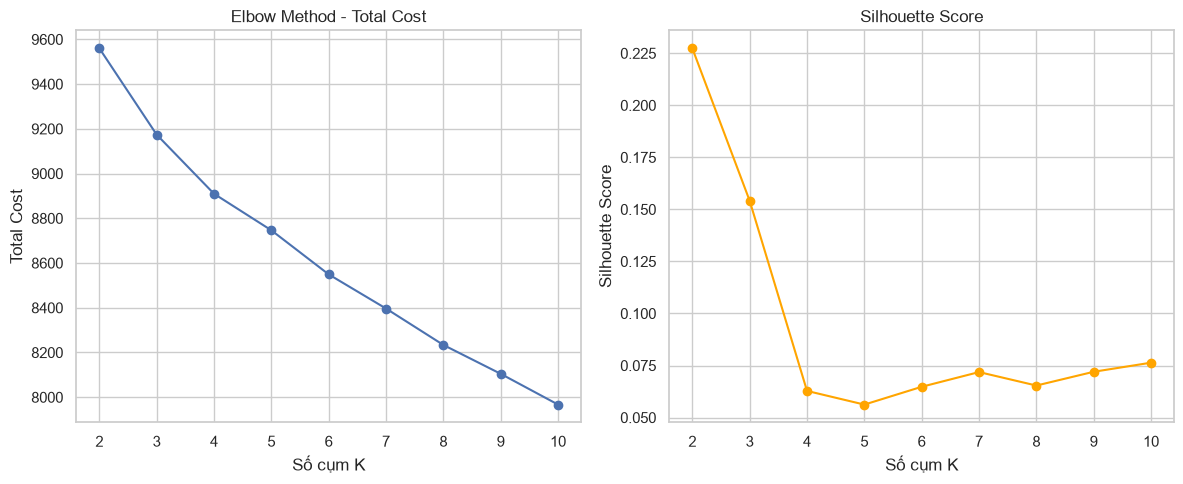

In [7]:
# ==============================================================================
# TRỰC QUAN HÓA ELBOW METHOD
# ==============================================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, total_cost_list, marker='o')
plt.title('Elbow Method - Total Cost')
plt.xlabel('Số cụm K')
plt.ylabel('Total Cost')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_list, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Số cụm K')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

#### Nhận xét — Biểu đồ Elbow & Silhouette

- **Elbow (Total Cost):** đường cong giảm mạnh từ K=2 đến K=4, sau đó giảm chậm dần — xác nhận **K = 4** là điểm khuỷu tay hợp lý.
- **Silhouette:** đạt đỉnh tại K=2, sau đó duy trì ở mức thấp (0,05–0,08). Với dữ liệu marketing đa chiều, chỉ số này thường thấp hơn so với dữ liệu có cấu trúc hình cầu rõ ràng.
- **Kết luận chọn K:** chọn **K = 4** dựa trên Elbow Method và khả năng diễn giải nghiệp vụ (4 chân dung khách hàng khác biệt).


### **[GIAI ĐOẠN 4]: ĐÁNH GIÁ & BÁO CÁO KẾT QUẢ**
- Huấn luyện mô hình K-Medoids cuối cùng.
- Bảng phân tích đặc trưng chân dung phân khúc khách hàng.
- Xuất file CSV kết quả phân cụm.
- Trực quan hoá kết quả gom cụm tối ưu.


In [20]:
# ==============================================================================
# CHỌN MÔ HÌNH K TỐI ƯU (tái sử dụng từ vòng quét K, không train lại)
# ==============================================================================

optimal_k = 4   # Thay đổi dựa trên kết quả Elbow / Silhouette ở trên

final_model = models_k[optimal_k]
df['Cluster'] = final_model.labels

print("=== SỐ LƯỢNG KHÁCH HÀNG TRONG MỖI PHÂN KHÚC ===")
print(df['Cluster'].value_counts().sort_index())

print("\n=== MEDOID ĐẠI DIỆN TỪNG CỤM (index hàng trong df) ===")
for cluster_id, medoid_idx in enumerate(final_model.medoid_indices_):
    print(f"  Cụm {cluster_id}: medoid_indices_ = {medoid_idx}")

=== SỐ LƯỢNG KHÁCH HÀNG TRONG MỖI PHÂN KHÚC ===
Cluster
0    623
1    599
2    603
3    412
Name: count, dtype: int64

=== MEDOID ĐẠI DIỆN TỪNG CỤM (index hàng trong df) ===
  Cụm 0: medoid_indices_ = 234
  Cụm 1: medoid_indices_ = 841
  Cụm 2: medoid_indices_ = 766
  Cụm 3: medoid_indices_ = 364


#### Nhận xét — Phân bố cụm và Medoids (K = 4)

| Cụm | Số KH | Tỷ lệ | Medoid (index) |
|---|---:|---:|---:|
| 0 | 623 | 27,9% | 234 |
| 1 | 599 | 26,8% | 841 |
| 2 | 603 | 27,0% | 766 |
| 3 | 412 | 18,4% | 364 |

- Bốn cụm **cân bằng tương đối** (trừ Cụm 3 nhỏ hơn ~18%), tránh tình trạng một cụm chiếm đa số.
- **Medoid** là khách hàng thực tế đại diện cho cụm — có thể tra cứu trực tiếp trong `df` để xem hồ sơ cụ thể, hữu ích cho đội CRM khi xây dựng persona.
- Total Cost tại K=4: **8.909,62** (so với 9.560 tại K=2, giảm ~6,8%).


In [21]:
# ==============================================================================
# BẢNG PHÂN TÍCH CHÂN DUNG PHÂN KHÚC KHÁCH HÀNG TƯƠNG ỨNG VỚI K TỐI ƯU
# ==============================================================================

cluster_summary = df.groupby('Cluster').mean().T

# Tạo style trang trí cho bảng
styled_output = cluster_summary.style \
    .background_gradient(cmap='YlGnBu', axis=1) \
    .format("{:,.2f}") \
    .set_caption("BẢNG PHÂN TÍCH ĐẶC TRƯNG CHÂN DUNG CÁC PHÂN KHÚC KHÁCH HÀNG") \
    .set_properties(**{
        'text-align': 'right',
        'padding': '8px',
        'font-size': '13px',
        'border-bottom': '1px solid #e6e6e6'
    }) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f7f9fa'), ('color', '#333'), ('font-weight', 'bold')]},
        {'selector': 'caption', 'props': [('caption-side', 'top'), ('color', '#f7f9fa'), ('font-size', '16px')]}
    ])

# Gọi bảng ra để hiển thị trực tiếp trong Jupyter Notebook
styled_output

Cluster,0,1,2,3
Education,0.02,-0.06,0.34,-0.43
Marital_Status,0.59,-0.04,0.14,-1.05
Income,-0.68,0.97,0.21,-0.68
MntWines,-0.78,0.84,0.47,-0.73
MntFruits,-0.53,1.03,-0.16,-0.46
MntMeatProducts,-0.64,1.24,-0.16,-0.60
MntFishProducts,-0.55,1.16,-0.24,-0.50
MntSweetProducts,-0.53,1.02,-0.16,-0.46
MntGoldProds,-0.57,0.60,0.31,-0.46
NumDealsPurchases,-0.24,-0.50,0.79,-0.08


#### Nhận xét — Chân dung 4 phân khúc khách hàng

*(Giá trị trong bảng là trung bình đã chuẩn hóa; dương = cao hơn trung bình toàn tập, âm = thấp hơn)*

**Cụm 1 — Khách hàng giá trị cao (VIP)** · 599 KH
- Thu nhập cao (+0,97), chi tiêu vượt trội mọi nhóm sản phẩm (thịt +1,24, trái cây +1,03, catalogue +1,14).
- Ít con (-0,94), ít duyệt web (-1,06), mua chủ yếu qua catalogue & cửa hàng.
- Phản hồi chiến dịch tích cực (AcceptedCmp5 +0,64, Response +0,31).
- *Chiến lược:* chương trình loyalty cao cấp, ưu đãi cá nhân hóa sản phẩm cao cấp (rượu, thịt).

**Cụm 2 — Khách hàng số / săn ưu đãi** · 603 KH
- Mua web (+0,81) và khuyến mãi (+0,79) cao, tuổi lớn hơn (+0,44), trình độ học vấn cao (+0,34).
- Gắn bó lâu (+0,32 DaysCustomer), chi tiêu trung bình-khá.
- *Chiến lược:* email marketing, flash sale, ưu đãi online, retargeting web.

**Cụm 0 — Gia đình chi tiêu thấp** · 623 KH
- Thu nhập thấp (-0,68), chi tiêu thấp toàn danh mục, nhiều con hơn (+0,33).
- Duyệt web nhiều (+0,34) nhưng mua ít — quan tâm nhưng chưa chuyển đổi.
- *Chiến lược:* gói combo gia đình giá mềm, khuyến mãi theo mùa, nuôi dưỡng từ awareness → purchase.

**Cụm 3 — Khách thụ động / ít tương tác** · 412 KH
- Cụm nhỏ nhất, chi tiêu và thu nhập đều thấp, duyệt web cao nhất (+0,61) nhưng không mua.
- Tình trạng hôn nhân khác biệt (-1,05 so với trung bình).
- *Chiến lược:* khảo sát nhu cầu, ưu đãi kích hoạt lần mua đầu, remarketing nhẹ nhàng.


In [ ]:
# ==============================================================================
# XUẤT FILE CSV KẾT QUẢ PHÂN CỤM
# ==============================================================================

# Xuất ra file CSV kết quả
output_path = 'customer_personality_clustered_v2.csv'
df.to_csv(output_path, index=False)

print(f"Đã xuất file CSV thành công: {output_path}")
print(f"   Kích thước file: {df.shape[0]} dòng x {df.shape[1]} cột")
print(f"\nPhân bố các cụm:")
print(df['Cluster'].value_counts().sort_index().to_string())
print(f"\n5 dòng đầu tiên:")
print(df.head())

Đã xuất file CSV thành công: customer_personality_clustered_v2.csv
   Kích thước file: 2237 dòng x 25 cột

Phân bố các cụm:
Cluster
0    623
1    599
2    603
3    412

5 dòng đầu tiên:
   Education  Marital_Status    Income  MntWines  MntFruits  MntMeatProducts  \
0  -0.819827       -1.348103  0.235681  0.983671   1.554623         1.680253   
1  -0.819827       -1.348103 -0.235144 -0.870717  -0.636422        -0.713250   
2  -0.819827        0.741783  0.773613  0.362570   0.572430        -0.176928   
3  -0.819827        0.741783 -1.021503 -0.870717  -0.560868        -0.651196   
4   1.529387        0.741783  0.241868 -0.389289   0.421324        -0.216820   

   MntFishProducts  MntSweetProducts  MntGoldProds  NumDealsPurchases  ...  \
0         2.461700          1.475877      0.846061           0.348371  ...   
1        -0.650275         -0.631440     -0.729569          -0.169096  ...   
2         1.345050         -0.147000     -0.037829          -0.686563  ...   
3        -0.503829   

#### Nhận xét — Xuất dữ liệu kết quả

- File `customer_personality_clustered_v2.csv` lưu toàn bộ 24 đặc trưng gốc + cột `Cluster`, phục vụ import vào CRM, BI dashboard hoặc mô hình downstream.
- Mỗi dòng tương ứng một khách hàng với nhãn phân khúc cố định — có thể join với ID gốc nếu cần truy vết.


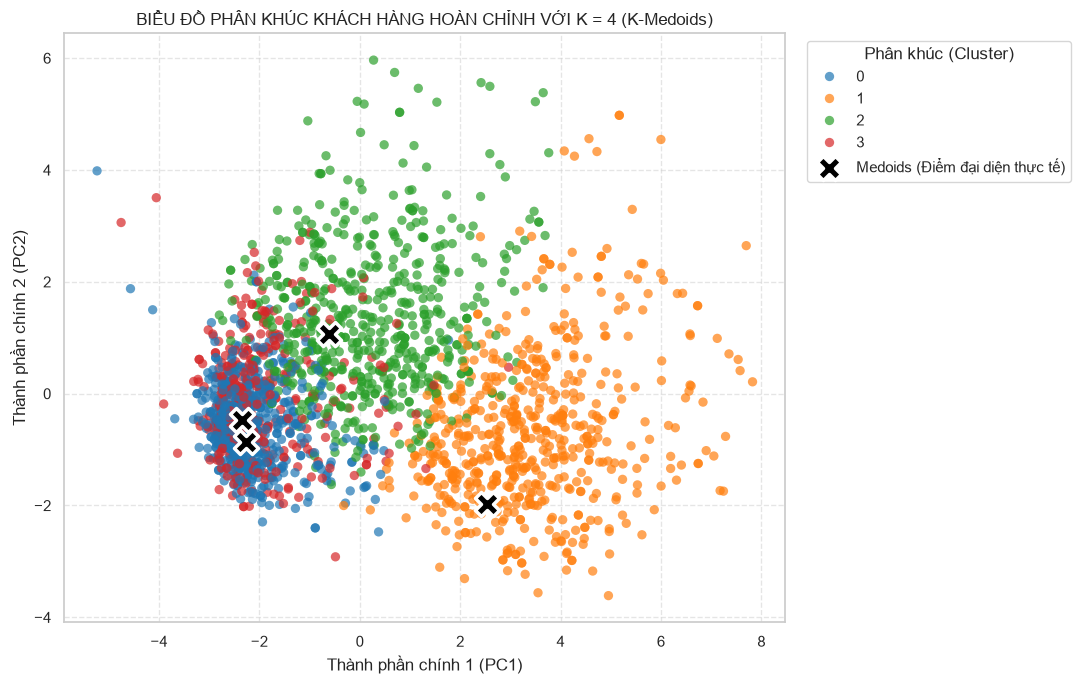

In [23]:
# ==============================================================================
# TRỰC QUAN HÓA KẾT QUẢ GOM CỤM TỐI ƯU (K-MEDOIDS)
# ==============================================================================

# 1. Lấy nhãn cụm
cluster_labels = df['Cluster'].values

# 2. Chiếu các Medoids (điểm thực tế) xuống không gian PCA 2D
medoids_pca = pca_transform(final_model.medoids, pca_components, X_mean)

# 3. Vẽ biểu đồ phân tán các điểm dữ liệu
plt.figure(figsize=(11, 7))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=cluster_labels, 
    palette='tab10', 
    alpha=0.7, 
    s=45, 
    edgecolor='none'
)

# 4. Vẽ các Medoids (điểm đại diện thực tế) lên biểu đồ
plt.scatter(
    medoids_pca[:, 0], medoids_pca[:, 1], 
    color='black', 
    marker='X', 
    s=300, 
    label='Medoids (Điểm đại diện thực tế)', 
    edgecolor='white', 
    linewidth=2.5
)

# 5. Cấu hình hiển thị
plt.title(f'BIỂU ĐỒ PHÂN KHÚC KHÁCH HÀNG HOÀN CHỈNH VỚI K = {final_model.n_clusters} (K-Medoids)')
plt.xlabel('Thành phần chính 1 (PC1)')
plt.ylabel('Thành phần chính 2 (PC2)')
plt.legend(title='Phân khúc (Cluster)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Nhận xét — Trực quan hóa phân khúc (PCA 2D)

- Bốn cụm hiển thị **chồng lấn một phần** trên mặt phẳng PCA — bình thường vì PCA chỉ giữ 2 chiều tổng hợp từ 24 chiều gốc.
- Các **medoid (dấu X đen)** nằm gần trung tâm mật độ từng nhóm màu, xác nhận chúng là điểm đại diện hợp lý.
- Sự phân tách rõ nhất quan sát được giữa **Cụm 1 (VIP)** và **Cụm 0/3 (chi tiêu thấp)** theo trục PC1 — phản ánh trục chi tiêu/thu nhập là yếu tố phân cụm chính.


---

## Kết luận

Notebook đã hoàn thành pipeline **phân khúc khách hàng bằng K-Medoids (PAM) từ scratch** trên tập Customer Personality Analysis:

1. Dữ liệu 2.237 khách hàng × 24 đặc trưng đã chuẩn hóa được phân thành **4 phân khúc** có ý nghĩa nghiệp vụ.
2. Thuật toán PAM với K-Medoids++ hội tụ ổn định; medoid giúp mỗi cụm có **đại diện thực tế** dễ diễn giải.
3. Bốn chân dung chính: **VIP cao cấp**, **khách hàng số/săn deal**, **gia đình chi tiêu thấp**, **khách thụ động**.
4. Kết quả được xuất ra CSV và bảng chân dung, sẵn sàng triển khai chiến lược marketing theo từng phân khúc thay vì tiếp cận đại trà.

> **Gợi ý mở rộng:** so sánh với K-Means, thử PCA trước khi phân cụm, hoặc kết hợp RFM để đánh giá chéo chất lượng phân khúc.
